# MISO load duration curve

Compare actual and modeled electricity demand for the sum of six MISO
subregions in 2023. A **load duration curve** sorts hourly demand from
highest to lowest, showing how often different load levels occur.

**Inputs:** six actual-load CSVs and six saved subregion-forecast CSVs,
all bundled with this repository. All times are UTC and all loads are in MW.

**Requirements:** the repository environment. No download or model training is needed.

**Outputs:** one figure displayed below and saved as
`data_outputs/analysis/miso_load_duration_curve/miso_2023_load_duration_curve.png`.

Run the code cells from top to bottom. See the [setup instructions](../../README.md#quick-start).
In Jupyter, **Restart Kernel and Run All** runs the complete example.

The total represents the six listed subregions; it is not the separately
reported direct-MISO series.

## Setup

This example uses the six bundled subregion IDs below. Paths are relative
to this notebook's `notebooks/analysis/` folder: `../../` moves up to the
repository root. The output folder is created if it does not already exist.
Keep `YEAR = 2023` when using the bundled inputs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

YEAR = 2023
MISO_SUBREGIONS = ["0001", "0004", "0006", "0027", "0035", "8910"]
ACTUAL_LOAD_DIR = Path("../../data_inputs/load_actuals/cleaned_2023")
MODELED_LOAD_DIR = Path(
    "../../data_inputs/validation/load_forecast/miso_subregion_predictions_2023"
)
OUTPUT_DIR = Path("../../data_outputs/analysis/miso_load_duration_curve")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Shared presentation defaults; data values and plot limits are set below.
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "normal",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "legend.frameon": False,
        "grid.color": "#d1d5db",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.65,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    }
)

## Step 1: Read actual load for each subregion

Read one CSV at a time, convert its timestamps to UTC, and use those
timestamps as the row index. Combine the six series into a table with
one column per subregion and one row per hour.

Use **`load_actual_mw_raw`**, which retains the original observations,
including values flagged during cleaning. Although the files are in
`cleaned_2023/`, this example does not use `load_actual_mw_clean`.
Rename the selected columns to match the modeled files in the next step.

The preview shows the first three hours. Rounding changes only the preview.

In [2]:
actual_by_subregion = {}

for region in MISO_SUBREGIONS:
    file_path = ACTUAL_LOAD_DIR / f"MISO_{region}_cleaned_load_{YEAR}.csv"
    load = pd.read_csv(
        file_path,
        usecols=["time_utc", "load_actual_mw_raw"],
        dtype={"load_actual_mw_raw": "int64"},
    )
    load = load.rename(
        columns={
            "time_utc": "Time_UTC",
            "load_actual_mw_raw": "Load",
        }
    )
    load["Time_UTC"] = pd.to_datetime(load["Time_UTC"], utc=True)
    load = load.set_index("Time_UTC")
    assert load.index.is_unique, f"Duplicate actual-load timestamps for {region}."
    actual_by_subregion[region] = load["Load"]

actual_table = pd.concat(actual_by_subregion, axis=1)
actual_table.head(3).round(1)

,0001,0004,0006,0027,0035,8910
Time_UTC,,,,,,
2023-01-01 00:00:00+00:00,11598,5134,9215,17098,9946,17168
2023-01-01 01:00:00+00:00,11453,5046,9169,16696,9825,17404
2023-01-01 02:00:00+00:00,11142,4937,9045,16253,9590,17167


## Step 2: Read modeled load for the same subregions

Repeat the same sequence for the six saved forecasts. These files already
use `Time_UTC` and `Load` as their column names. This step reads existing
model results; it does not fit or run a forecasting model.

The preview should have the same six subregion columns as the actual-load table.

In [3]:
modeled_by_subregion = {}

for region in MISO_SUBREGIONS:
    file_path = MODELED_LOAD_DIR / f"{region}_{YEAR}_mlp_output_bchrrr_nsrdb.csv"
    load = pd.read_csv(file_path, usecols=["Time_UTC", "Load"])
    load["Time_UTC"] = pd.to_datetime(load["Time_UTC"], utc=True)
    load = load.set_index("Time_UTC")
    assert load.index.is_unique, f"Duplicate modeled-load timestamps for {region}."
    modeled_by_subregion[region] = load["Load"]

modeled_table = pd.concat(modeled_by_subregion, axis=1)
modeled_table.head(3).round(1)

,0001,0004,0006,0027,0035,8910
Time_UTC,,,,,,
2023-01-01 00:00:00+00:00,11161.8,5211.5,9544.6,17134.4,9664.5,16978.8
2023-01-01 01:00:00+00:00,11177.5,5268.3,9693.0,17136.8,9691.0,17297.8
2023-01-01 02:00:00+00:00,11029.7,5288.0,9727.2,16902.4,9677.1,17524.1


## Step 3: Sum the subregions and check the hourly alignment

Add across the six columns to calculate total actual and total modeled
load for each hour. `min_count=6` requires a value from every subregion;
an incomplete total remains missing instead of silently treating missing
load as zero.

Join the two totals by timestamp, put the rows in chronological order,
and keep 2023. The checks require exactly the expected **8,760 UTC hours**
and no missing actual or modeled totals. The preview now has two columns:
actual load and modeled load at the same hour.

In [4]:
actual = actual_table.sum(axis=1, min_count=len(MISO_SUBREGIONS)).rename("actual_load_mw")
modeled = modeled_table.sum(axis=1, min_count=len(MISO_SUBREGIONS)).rename("modeled_load_mw")

hourly = pd.concat([actual, modeled], axis=1, join="inner")
hourly = hourly.sort_index()
hourly = hourly.loc[hourly.index.year == YEAR]

expected_hours = pd.date_range(
    start=f"{YEAR}-01-01",
    end=f"{YEAR + 1}-01-01",
    freq="h",
    inclusive="left",
    tz="UTC",
)
assert hourly.index.equals(expected_hours), "Expected every UTC hour of 2023 exactly once."
assert hourly.notna().all().all(), "At least one hour has an incomplete subregion total."

print(f"Checked {len(hourly):,} complete UTC hours for {YEAR}.")
hourly.head(3).round(1)

Checked 8,760 complete UTC hours for 2023.


,actual_load_mw,modeled_load_mw
Time_UTC,,
2023-01-01 00:00:00+00:00,70159,69695.5
2023-01-01 01:00:00+00:00,69593,70264.4
2023-01-01 02:00:00+00:00,68134,70148.5


## Step 4: Sort each load series from highest to lowest

Sort actual and modeled load **independently**. The first value in each
sorted array is its annual maximum; the last is its annual minimum.
These arrays describe the load distributions, so their corresponding
positions no longer necessarily refer to the same timestamp.

Space the plotting positions evenly from 0% to 100% of annual hours.
Keep `hourly` in chronological order for the pale-blue trace.

In [5]:
actual_sorted = np.sort(hourly["actual_load_mw"].to_numpy())[::-1]
modeled_sorted = np.sort(hourly["modeled_load_mw"].to_numpy())[::-1]
percent_of_year = np.linspace(0, 100, len(hourly))

## Step 5: Plot, save, and display the comparison

Draw the sorted actual and modeled curves, then add chronological actual
load for context. Use the same axis limits and units for all three traces.
Save the PNG before displaying and closing the figure.

Wrote load-duration figure: ../../data_outputs/analysis/miso_load_duration_curve/miso_2023_load_duration_curve.png


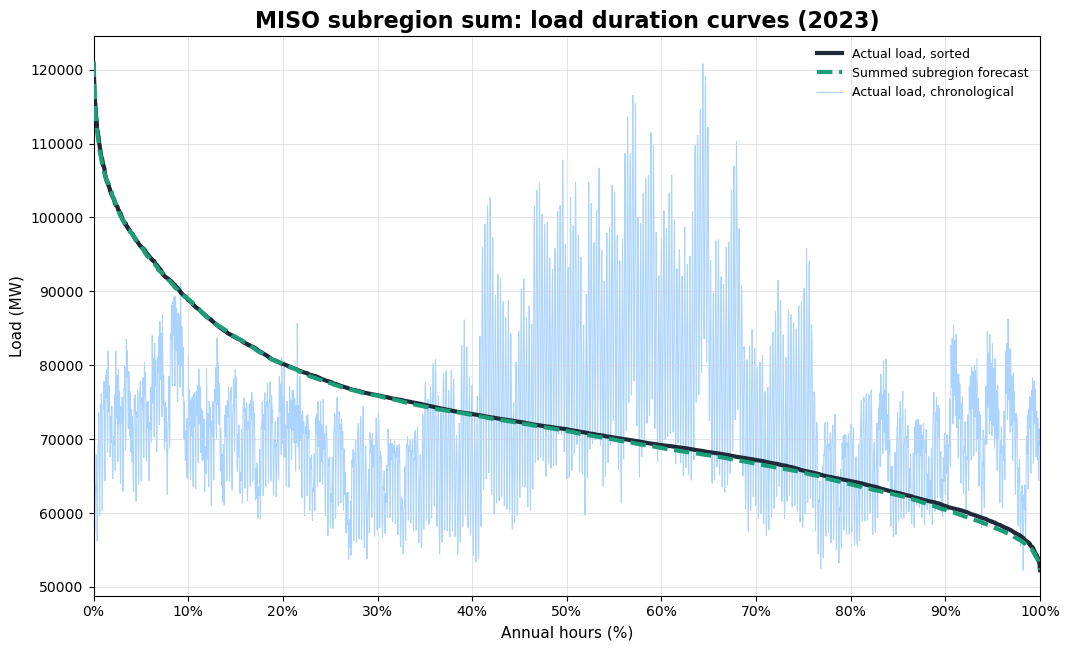

In [6]:
fig, ax = plt.subplots(figsize=(10.8, 6.6))
ax.plot(
    percent_of_year,
    actual_sorted,
    color="#1f2937",
    linewidth=3.0,
    label="Actual load, sorted",
    zorder=4,
)
ax.plot(
    percent_of_year,
    modeled_sorted,
    color="#1b9e77",
    linewidth=3.0,
    linestyle="--",
    label="Summed subregion forecast",
    zorder=5,
)
ax.plot(
    percent_of_year,
    hourly["actual_load_mw"],
    color="#8ec5ff",
    linewidth=0.7,
    alpha=0.75,
    label="Actual load, chronological",
    zorder=1,
)

ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 10))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.set_xlabel("Annual hours (%)")
ax.set_ylabel("Load (MW)")
ax.set_title("MISO subregion sum: load duration curves (2023)", fontsize=16, fontweight="bold")
ax.grid(True, color="#d1d5db", linewidth=0.7, alpha=0.65)
ax.legend(loc="upper right", frameon=False)
fig.tight_layout()

output_path = OUTPUT_DIR / "miso_2023_load_duration_curve.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")
print(f"Wrote load-duration figure: {output_path.as_posix()}")
plt.show()
plt.close(fig)

## Interpretation

- **Dark gray:** actual load sorted from highest to lowest. Near 10% on
  the horizontal axis, the curve shows a load level met or exceeded for
  approximately 10% of the year's hours.
- **Dashed green:** modeled load sorted the same way. Compare it with the
  gray curve to see whether the model reproduces high, middle, and low
  load levels. Agreement here does not establish that peaks occurred at
  the correct times.
- **Pale blue:** actual load in chronological order. For this trace, the
  horizontal position is progress through the year, from January to
  December, rather than a sorted-load rank. It is not a duration curve.

The saved PNG contains the same figure. The three input previews and the
hourly checks above show how the six subregion series became the totals
used in that figure.